In [9]:
import pandas as pd

# Carica il dataset
df = pd.read_csv('train.csv')

# Visualizza le prime 5 righe per controllare che sia tutto ok
print(df.head())

   id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   0    Male              0     Yes        Yes      29          Yes   
1   1    Male              0     Yes        Yes      58          Yes   
2   2    Male              0     Yes         No      58          Yes   
3   3  Female              0      No         No       1          Yes   
4   4  Female              0      No         No       1          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL            Yes  ...              Yes   
1            No             DSL            Yes  ...               No   
2           Yes     Fiber optic             No  ...               No   
3            No     Fiber optic             No  ...               No   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0         Yes          No              No        One yea

In [10]:
df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [12]:
df.nunique()

id                  594194
gender                   2
SeniorCitizen            2
Partner                  2
Dependents               2
tenure                  72
PhoneService             2
MultipleLines            3
InternetService          3
OnlineSecurity           3
OnlineBackup             3
DeviceProtection         3
TechSupport              3
StreamingTV              3
StreamingMovies          3
Contract                 3
PaperlessBilling         2
PaymentMethod            4
MonthlyCharges        1921
TotalCharges         31910
Churn                    2
dtype: int64

In [13]:
df = df.drop('id', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [14]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   gender            594194 non-null  category
 1   SeniorCitizen     594194 non-null  int64   
 2   Partner           594194 non-null  category
 3   Dependents        594194 non-null  category
 4   tenure            594194 non-null  int64   
 5   PhoneService      594194 non-null  category
 6   MultipleLines     594194 non-null  category
 7   InternetService   594194 non-null  category
 8   OnlineSecurity    594194 non-null  category
 9   OnlineBackup      594194 non-null  category
 10  DeviceProtection  594194 non-null  category
 11  TechSupport       594194 non-null  category
 12  StreamingTV       594194 non-null  category
 13  StreamingMovies   594194 non-null  category
 14  Contract          594194 non-null  category
 15  PaperlessBilling  594194 non-null  category
 16  Pa

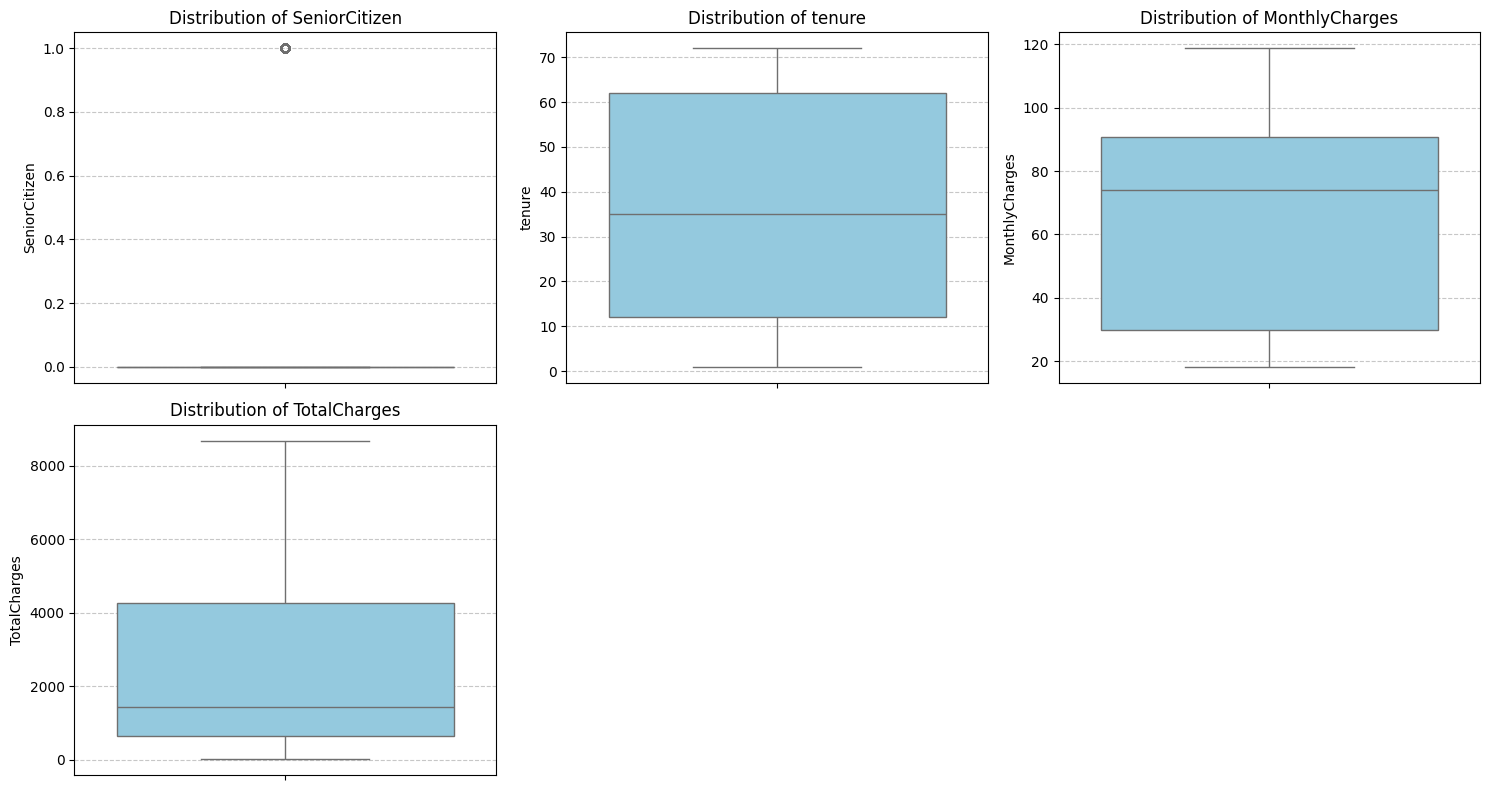

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Setup the grid dimensions (e.g., 3 columns per row)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the figure
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Final adjustments and saving
plt.tight_layout()
plt.savefig('numeric_boxplots.png')

In [16]:
# Isolate the target
y = df['Churn'].copy()

# Drop the target from the main DataFrame to create the feature set
X = df.drop(columns=['Churn'])

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (594194, 19)
Target shape: (594194,)


In [17]:
# 1. Average Monthly Spend (Verify if TotalCharges matches tenure * MonthlyCharges)
# We add 1 to tenure to avoid division by zero for new customers
X['Avg_Monthly_Spend'] = X['TotalCharges'] / (X['tenure'] + 1)

# 2. Tenure in Years (Easier for some models to parse than months)
X['Tenure_Years'] = X['tenure'] / 12

# 3. Charges Ratio (Is the current monthly charge higher than the historical average?)
X['Charge_Ratio'] = X['MonthlyCharges'] / (X['Avg_Monthly_Spend'] + 0.01)

In [18]:
# 6. Is Short Term Contract
X['Is_Month_To_Month'] = (X['Contract'] == 'Month-to-month').astype(int)

# 7. High Risk Payment (Electronic check is often correlated with higher churn)
X['Is_Electronic_Check'] = (X['PaymentMethod'] == 'Electronic check').astype(int)

In [35]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# 1. Prepare Data
y_numeric = y.cat.codes if hasattr(y, 'cat') else y
X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric)

# Create DMatrix objects (native format for XGBoost)
# enable_categorical=True here handles your 'category' columns automatically
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'tree_method': 'hist', # Required for categorical data
        'n_jobs' : -1,
        
        # Hyperparameters
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', ratio * 0.8, ratio * 1.2),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        
    }

    # The Pruning Callback
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, 'eval-logloss')

    # Use native xgb.train instead of XGBClassifier
    bst = xgb.train(
        param, 
        dtrain, 
        num_boost_round=1000,
        evals=[(dtest, 'eval')],
        callbacks=[pruning_callback],
        verbose_eval=False
    )
    
    # Predict and convert probabilities to binary (0 or 1)
    preds_prob = bst.predict(dtest)
    preds = [1 if p > 0.5 else 0 for p in preds_prob]
    
    return f1_score(y_test, preds)

# 2. Run the Optuna Study
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(
    direction='maximize', 
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
study.optimize(objective, n_trials=5, show_progress_bar=True)

print(f"\nBest accuracy: {study.best_trial.value:.4f}")
print(f"Best parameters: {study.best_params}")

[I 2026-03-04 14:31:37,353] A new study created in memory with name: no-name-cb721fd6-9e85-4b71-87bc-945e501a9fbe
Best trial: 0. Best value: 0.690874:  20%|██        | 1/5 [00:32<02:09, 32.39s/it]

[I 2026-03-04 14:32:09,742] Trial 0 finished with value: 0.6908744604703316 and parameters: {'scale_pos_weight': 3.0401286974749837, 'lambda': 0.00026961420623986324, 'alpha': 1.6166819643043204e-06, 'subsample': 0.8702041341497437, 'colsample_bytree': 0.7111607522986363, 'max_depth': 7, 'learning_rate': 0.1345000541452968, 'min_child_weight': 2}. Best is trial 0 with value: 0.6908744604703316.


Best trial: 0. Best value: 0.690874:  40%|████      | 2/5 [01:17<02:00, 40.07s/it]

[I 2026-03-04 14:32:55,188] Trial 1 finished with value: 0.6827709735198721 and parameters: {'scale_pos_weight': 3.209064321871703, 'lambda': 9.359459865462436e-06, 'alpha': 0.0003098718395111647, 'subsample': 0.8157359757058661, 'colsample_bytree': 0.5147160491069661, 'max_depth': 9, 'learning_rate': 0.18899613807608284, 'min_child_weight': 2}. Best is trial 0 with value: 0.6908744604703316.


Best trial: 0. Best value: 0.690874:  60%|██████    | 3/5 [01:42<01:06, 33.21s/it]

[I 2026-03-04 14:33:20,233] Trial 2 finished with value: 0.6825152712899748 and parameters: {'scale_pos_weight': 3.6401899414397216, 'lambda': 1.289205407186998e-08, 'alpha': 1.8326024521994716e-06, 'subsample': 0.5778331586731236, 'colsample_bytree': 0.6763212606636018, 'max_depth': 4, 'learning_rate': 0.03732698112818387, 'min_child_weight': 9}. Best is trial 0 with value: 0.6908744604703316.


Best trial: 0. Best value: 0.690874:  80%|████████  | 4/5 [02:18<00:34, 34.10s/it]

[I 2026-03-04 14:33:55,695] Trial 3 finished with value: 0.6820062569381371 and parameters: {'scale_pos_weight': 3.587460540286359, 'lambda': 3.5603819852804985e-08, 'alpha': 0.004138100332422518, 'subsample': 0.7415681237427585, 'colsample_bytree': 0.6504143641941482, 'max_depth': 6, 'learning_rate': 0.012502742583229604, 'min_child_weight': 5}. Best is trial 0 with value: 0.6908744604703316.


Best trial: 0. Best value: 0.690874: 100%|██████████| 5/5 [02:44<00:00, 32.93s/it]

[I 2026-03-04 14:34:21,981] Trial 4 finished with value: 0.6897978009552008 and parameters: {'scale_pos_weight': 3.199483100952336, 'lambda': 0.17194739026664824, 'alpha': 0.0012647499019989071, 'subsample': 0.9244078421859165, 'colsample_bytree': 0.7095809927583772, 'max_depth': 5, 'learning_rate': 0.13202755715474002, 'min_child_weight': 8}. Best is trial 0 with value: 0.6908744604703316.

Best accuracy: 0.6909
Best parameters: {'scale_pos_weight': 3.0401286974749837, 'lambda': 0.00026961420623986324, 'alpha': 1.6166819643043204e-06, 'subsample': 0.8702041341497437, 'colsample_bytree': 0.7111607522986363, 'max_depth': 7, 'learning_rate': 0.1345000541452968, 'min_child_weight': 2}


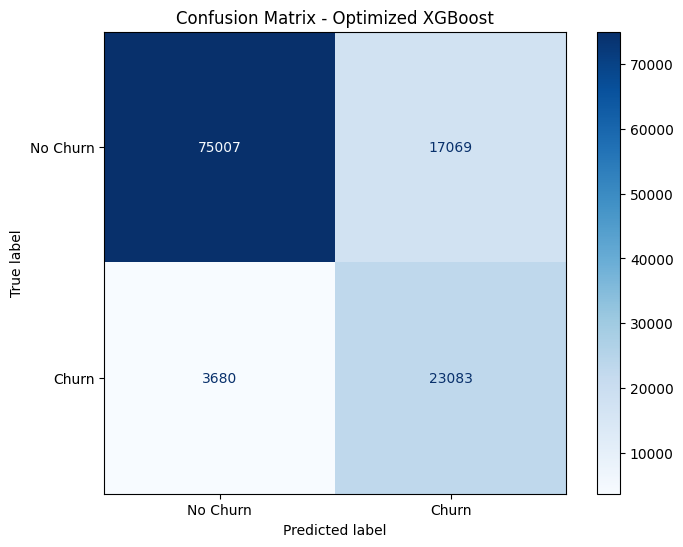

              precision    recall  f1-score   support

           0       0.95      0.81      0.88     92076
           1       0.57      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.83      0.84    118839



In [36]:
# 3. Final Model
best_params = study.best_params
# Re-add the mandatory parameters for categorical data
best_params.update({
    'enable_categorical': True,
    'tree_method': 'hist',
    'objective': 'binary:logistic'
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# 4. Evaluation and Confusion Matrix
y_pred = final_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - Optimized XGBoost')
plt.show()

# Print detailed metrics
print(classification_report(y_test, y_pred))

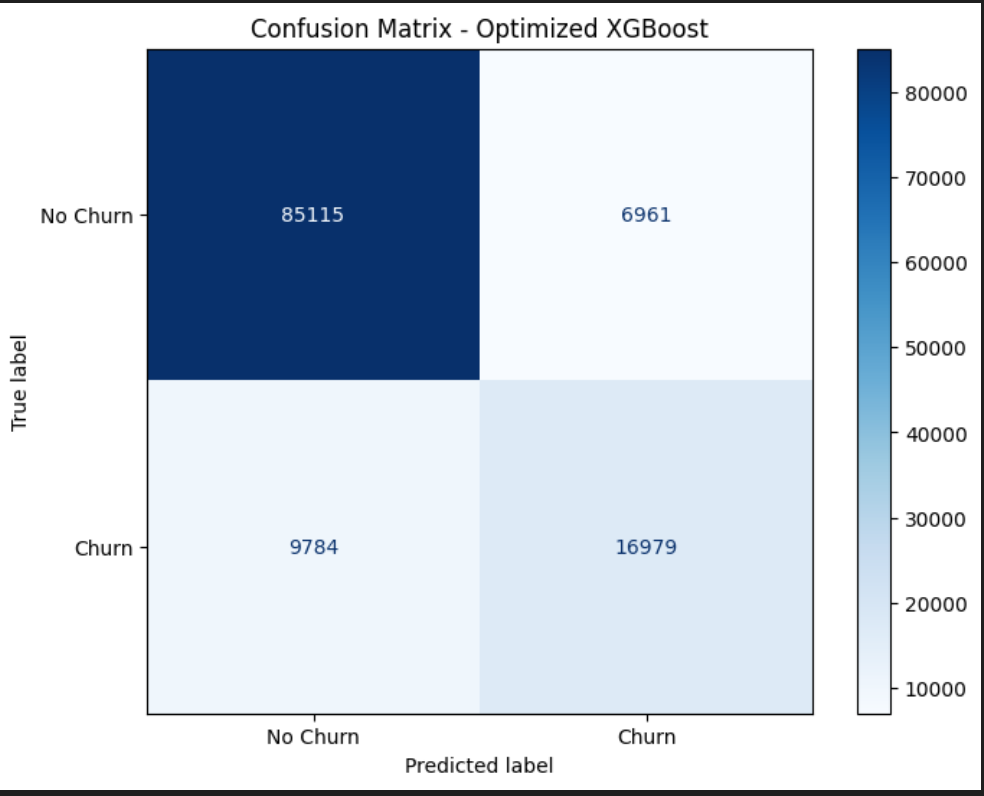